# NumPy Tutorial

NumPy is the foundation for all numerical computing in Python — every ML/AI library (PyTorch, TensorFlow, JAX, scikit-learn) builds on its array model.

**Why it matters for AI/LLM work:**
- Tensors in PyTorch are essentially NumPy arrays on GPU
- Shapes, broadcasting, and matrix multiplication are core to neural networks
- You'll read/write numpy code constantly when debugging models

Run each cell with `Shift+Enter`.

## Setup

In [56]:
import numpy as np
print(np.__version__)

2.4.6


## Quicksort test example

In [57]:
def quicksort(arr):
  if len(arr) <= 1:
    return arr
  pivot = arr[len(arr) // 2]
  left = [x for x in arr if x < pivot]
  middle = [x for x in arr if x == pivot]
  right = [x for x in arr if x > pivot]
  return quicksort(left) + middle + quicksort(right)

print(quicksort([20,6,8,10,1,2,1]))

[1, 1, 2, 6, 8, 10, 20]


## 1. Numpy Array

In [58]:
a = np.array([1,2,3,4])
print(type(a))
print(a.shape)
print(a[0], a[1], a[2])
a[0] = 6
print(a)

b = np.array([[1,2,3], [4,5,6]])
print(b.shape)
print(b[0,0], b[0,1], b[1,0])

<class 'numpy.ndarray'>
(4,)
1 2 3
[6 2 3 4]
(2, 3)
1 2 4


In [59]:
a = np.zeros((2,2))
print(a)

b = np.ones((1,2))
print(b)

c = np.full((2,2), 5)
print(c)

d = np.eye(2)
print(d)

e = np.random.random((2,2))
print(e)

[[0. 0.]
 [0. 0.]]
[[1. 1.]]
[[5 5]
 [5 5]]
[[1. 0.]
 [0. 1.]]
[[0.92392173 0.4607629 ]
 [0.53177058 0.81115929]]


## 2. Array indexing

Mixing integer indexing with slice indexing

In [60]:
a = np.array([[1,2,3,4], [5,6,7,8], [9,10,11,12]])
b = a[:2, 1:3]
print(a[0, 1])
b[0,0]=77
print(a[0,1])

row_r1 = a[1, :]
row_r2 = a[1:2, :]
print(row_r1, row_r1.shape)
print(row_r2, row_r2.shape)

col_c1 = a[:, 1]
col_c2 = a[:, 1:2]
print(col_c1, col_c1.shape)
print(col_c2, col_c2.shape)

2
77
[5 6 7 8] (4,)
[[5 6 7 8]] (1, 4)
[77  6 10] (3,)
[[77]
 [ 6]
 [10]] (3, 1)


Constructing arbitrary array using integer indexing.

In [61]:
a = np.array([[1,2], [3,4], [5,6]])

print(a[[0,1,2], [0,1,0]])
print(np.array([a[0,0], a[1,1], a[2,0]]))

print(a[[0,0], [1,1]])
print(np.array([a[0,1], a[0,1]]))

[1 4 5]
[1 4 5]
[2 2]
[2 2]


In [62]:
a = np.array([[1,2,3], [4,5,6], [7,8,9], [10,11,12]])
print(a)

b = np.array([0,2,0,1])

print(a[np.arange(4), b])

a[np.arange(4), b] += 10

print(a)

[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]
[ 1  6  7 11]
[[11  2  3]
 [ 4  5 16]
 [17  8  9]
 [10 21 12]]


**Boolean array indexing**:

Selecting an index based on a condition

In [63]:
a = np.array([[1,2], [3,4], [5,6]])

bool_idx = (a > 3)

print(type(bool_idx), "\n", bool_idx)

print(a[bool_idx])

print(a[a > 2])

<class 'numpy.ndarray'> 
 [[False False]
 [False  True]
 [ True  True]]
[4 5 6]
[3 4 5 6]


## Datatypes

In [64]:
x = np.array([1, 2])

print(x.dtype)

x = np.array([1.0, 2.0])

print(x.dtype)

x = np.array([1, 2], dtype=np.int16)

print(x.dtype)

int64
float64
int16


## Array Maths

In [65]:
x = np.array([[1,2], [3,4]], dtype=np.float64)
y = np.array([[5,6], [7,8]], dtype=np.float64)

print("Add")
print(x + y)
print(np.add(x, y))

print("Subtract")
print(x - y)
print(np.subtract(x, y))

print("Multiply")
print(x * y)
print(np.multiply(x, y))

print("Divide")
print(x / y)
print(np.divide(x, y))

print("Sqrt")
print(np.sqrt(x))

Add
[[ 6.  8.]
 [10. 12.]]
[[ 6.  8.]
 [10. 12.]]
Subtract
[[-4. -4.]
 [-4. -4.]]
[[-4. -4.]
 [-4. -4.]]
Multiply
[[ 5. 12.]
 [21. 32.]]
[[ 5. 12.]
 [21. 32.]]
Divide
[[0.2        0.33333333]
 [0.42857143 0.5       ]]
[[0.2        0.33333333]
 [0.42857143 0.5       ]]
Sqrt
[[1.         1.41421356]
 [1.73205081 2.        ]]


In [66]:
v = np.array([9, 10])
w = np.array([11, 12])

print(v.dot(w))
print(np.dot(v, w))

print(x.dot(v))
print(np.dot(x, v))

print(x.dot(y))
print(np.dot(x, y))

219
219
[29. 67.]
[29. 67.]
[[19. 22.]
 [43. 50.]]
[[19. 22.]
 [43. 50.]]


**Math function to perform operations of an array itself**

In [67]:
print("Array \n", x)
print("Sum of all elements = ", np.sum(x))
print("Sum of each column = ", np.sum(x, axis=0))
print("Sum of each row = ", np.sum(x, axis=1))
print("Transpose of x = \n", x.T)

v = np.array([1,2,3])
print(v)  
print(v.T)

Array 
 [[1. 2.]
 [3. 4.]]
Sum of all elements =  10.0
Sum of each column =  [4. 6.]
Sum of each row =  [3. 7.]
Transpose of x = 
 [[1. 3.]
 [2. 4.]]
[1 2 3]
[1 2 3]


## Broadcasting

Adding a vector into array without **broadcasting**

In [68]:
x = np.array([[1,2,3], [4,5,6], [7,8,9], [10, 11, 12]])
v = np.array([1, 0, 1])
y = np.empty_like(x)

for i in range(4):
  y[i, :] = x[i, :] + v

print(y)

[[ 2  2  4]
 [ 5  5  7]
 [ 8  8 10]
 [11 11 13]]


Adding a vector into array with the help of **tile**

In [69]:
vv = np.tile(v, (4, 1)) # Stack 4 copies of "v" on top of each other.
print(vv)

y = x + vv

print(y)

[[1 0 1]
 [1 0 1]
 [1 0 1]
 [1 0 1]]
[[ 2  2  4]
 [ 5  5  7]
 [ 8  8 10]
 [11 11 13]]


Adding with the help of **broadcasting**

In [70]:
yb = x + v
print(yb)

[[ 2  2  4]
 [ 5  5  7]
 [ 8  8 10]
 [11 11 13]]


In [71]:
print(x)
w = [[1], [0], [1], [2]]
yb2 = x + w
print(yb2)

[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]
[[ 2  3  4]
 [ 4  5  6]
 [ 8  9 10]
 [12 13 14]]


## SciPy

In [72]:
from scipy import ndimage
from PIL import Image

img = np.array(Image.open('./assets/input_cat.png'))
print(img.dtype, img.shape)

img_tinted = img * np.array([1, 0.95, 0.9])

zoom_factors = (300 / img.shape[0], 300 / img.shape[1], 1)
img_scaled = ndimage.zoom(img_tinted, zoom_factors)

img_scaled = np.uint8(np.clip(img_scaled, 0, 255))
Image.fromarray(img_scaled).save('./assets/output_cat.png')

uint8 (400, 248, 3)


### Distance between points

In [73]:
from scipy.spatial.distance import pdist, squareform


x = np.array([[0, 1], [1, 0], [2, 0]])
print(x)

d = squareform(pdist(x, 'euclidean'))
print(d)

[[0 1]
 [1 0]
 [2 0]]
[[0.         1.41421356 2.23606798]
 [1.41421356 0.         1.        ]
 [2.23606798 1.         0.        ]]


## Matplotlib

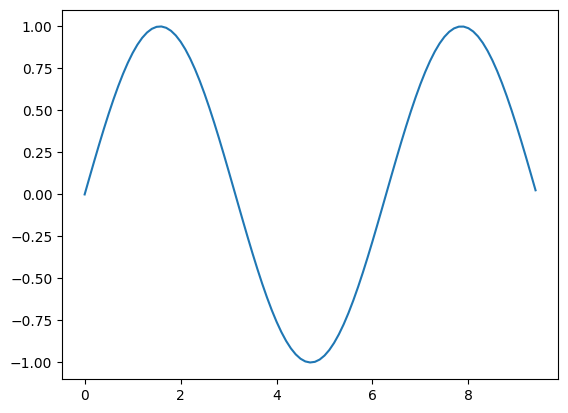

In [74]:
import matplotlib.pyplot as plt

x = np.arange(0, 3 * np.pi, 0.1)
y = np.sin(x)

plt.plot(x, y)
plt.show()

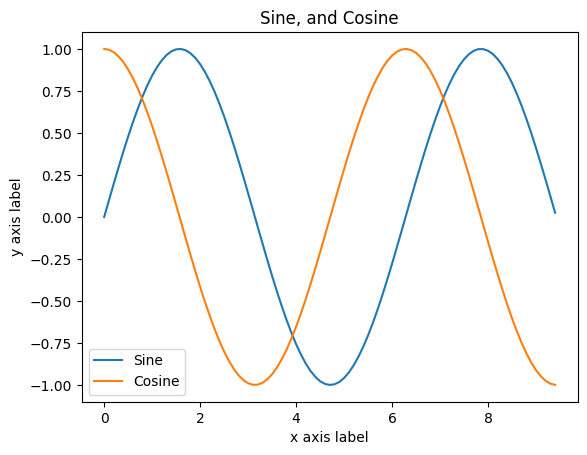

In [75]:
y_sin = np.sin(x)
y_cos = np.cos(x)

plt.plot(x, y_sin)
plt.plot(x, y_cos)

plt.xlabel('x axis label')
plt.ylabel('y axis label')

plt.title("Sine, and Cosine")
plt.legend(['Sine', 'Cosine'])

plt.show()

### Subplot

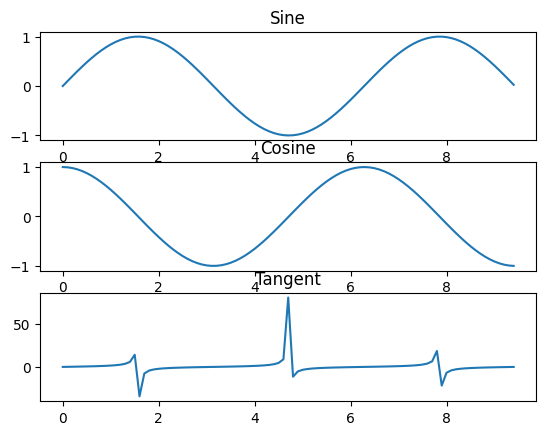

In [76]:
y_tan = np.tan(x)

plt.subplot(3, 1, 1)
plt.plot(x, y_sin)
plt.title("Sine")

plt.subplot(3, 1, 2)
plt.plot(x, y_cos)
plt.title("Cosine")

plt.subplot(3, 1, 3)
plt.plot(x, y_tan)
plt.title("Tangent")

plt.show()

### Images

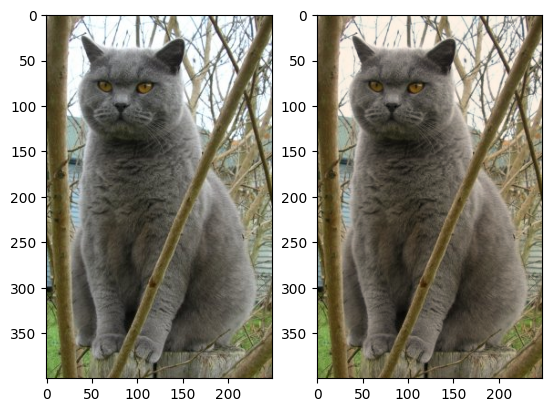

In [79]:
plt.subplot(1, 2, 1)
plt.imshow(img)

plt.subplot(1, 2, 2)
plt.imshow(np.uint8(img_tinted))
plt.show()